## 0. 환경 설정 및 라이브러리 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score, silhouette_score
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression


pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
RANDOM_STATE = 42

## 1. 데이터 로드
`bankchurners_clean.csv`(01_data_load_clean.ipynb에서 정제 완료: CLIENTNUM·Naive_Bayes 컬럼 제거, `Attrition_Flag`→`Target` 0/1 인코딩) 로드 후 `Target`을 이후 전체 셀에서 쓰는 `Churn`으로 이름만 맞춘다.

In [2]:
df = pd.read_csv('../data/processed/bankchurners_clean.csv')
df = df.rename(columns={'Target': 'Churn'})
df.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


## 2. 기본 탐색 (EDA)
결측치, 타입, 이탈률(Churn 비율) 확인 — 클래스 불균형 여부 체크.

In [3]:
print(df.info())
print(df.isna().sum().sum(), '개 결측치')
df['Churn'].value_counts(normalize=True)

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Age              10127 non-null  int64  
 1   Gender                    10127 non-null  str    
 2   Dependent_count           10127 non-null  int64  
 3   Education_Level           10127 non-null  str    
 4   Marital_Status            10127 non-null  str    
 5   Income_Category           10127 non-null  str    
 6   Card_Category             10127 non-null  str    
 7   Months_on_book            10127 non-null  int64  
 8   Total_Relationship_Count  10127 non-null  int64  
 9   Months_Inactive_12_mon    10127 non-null  int64  
 10  Contacts_Count_12_mon     10127 non-null  int64  
 11  Credit_Limit              10127 non-null  float64
 12  Total_Revolving_Bal       10127 non-null  int64  
 13  Avg_Open_To_Buy           10127 non-null  float64
 14  Total_Amt_Chng_Q4

Churn
0    0.83934
1    0.16066
Name: proportion, dtype: float64

## 3. 전처리
- 타겟: `Churn`은 1장에서 이미 0/1로 인코딩 완료 (분류용)
- 범주형(Gender, Education_Level, Marital_Status, Income_Category, Card_Category) 라벨/원핫 인코딩
- 수치형 스케일링(군집·회귀용)

In [4]:
cat_cols = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)

num_cols = df.select_dtypes(include=np.number).columns.drop('Churn').tolist()
scaler = StandardScaler()
df_scaled = df_enc.copy()
df_scaled[num_cols] = scaler.fit_transform(df_enc[num_cols])
df_scaled.shape

(10127, 33)

## 4. [분류] 이탈 위험 고객 예측 모델
**비즈니스 활용**: Marketing 팀 "이탈 위험군 리베이트 캠페인" 타겟 리스트 자동 산출. Operations CS 우선 응대 대상 선정에도 사용 가능.
- Logistic Regression(베이스라인) vs RandomForest/GradientBoosting 비교
- 클래스 불균형 고려해 class_weight='balanced' 적용

In [5]:
X = df_scaled.drop(columns=['Churn'])
y = df_scaled['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print('ROC-AUC:', roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1701
           1       0.87      0.85      0.86       325

    accuracy                           0.95      2026
   macro avg       0.92      0.91      0.92      2026
weighted avg       0.95      0.95      0.95      2026

ROC-AUC: 0.9856817256817256


### 4-1. 변수 중요도 (이탈에 영향을 주는 요인)
어떤 이용 패턴이 이탈과 연관되는지 확인 → 캠페인 메시지 설계에 반영.

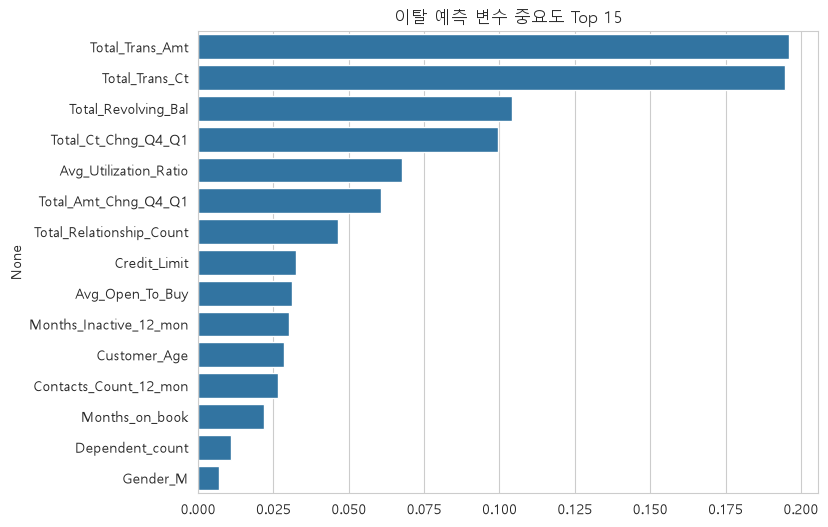

In [6]:
importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(8,6))
sns.barplot(x=importance.values, y=importance.index)
plt.title('이탈 예측 변수 중요도 Top 15')
plt.show()

### 4-2. 전체 고객 이탈 위험 점수 산출
전체 고객에 이탈 확률(risk score)을 부여 → 상위 N% 를 "이탈 위험군"으로 정의해 Marketing 캠페인 대상 테이블 생성.

In [7]:
df['churn_risk_score'] = clf.predict_proba(X)[:, 1]
risk_threshold = df['churn_risk_score'].quantile(0.85)
at_risk_customers = df[df['churn_risk_score'] >= risk_threshold]
print(f'이탈 위험군 기준 스코어: {risk_threshold:.3f}, 대상 고객 수: {len(at_risk_customers)}명')
at_risk_customers[['churn_risk_score', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Months_Inactive_12_mon']].sort_values('churn_risk_score', ascending=False).head(10)

이탈 위험군 기준 스코어: 0.727, 대상 고객 수: 1520명


,churn_risk_score,Total_Trans_Amt,Total_Trans_Ct,Months_Inactive_12_mon
5652,1.0,2147,44,2
5650,1.0,2312,44,3
5632,1.0,2205,43,2
473,1.0,654,14,2
467,1.0,929,31,3
451,1.0,706,21,3
406,1.0,1000,18,3
596,1.0,804,15,2
5602,1.0,2276,40,3
5559,1.0,2437,46,2


## 5. [군집] 고객 세그멘테이션
**비즈니스 활용**: Analytics 팀 고객 세그먼트 정의, Marketing 캠페인 그룹 타겟팅(저활동군 등).
- 이용금액/이용건수/거래횟수 변화 등 행동 변수로 K-Means 군집화
- Elbow/Silhouette로 군집 수 결정

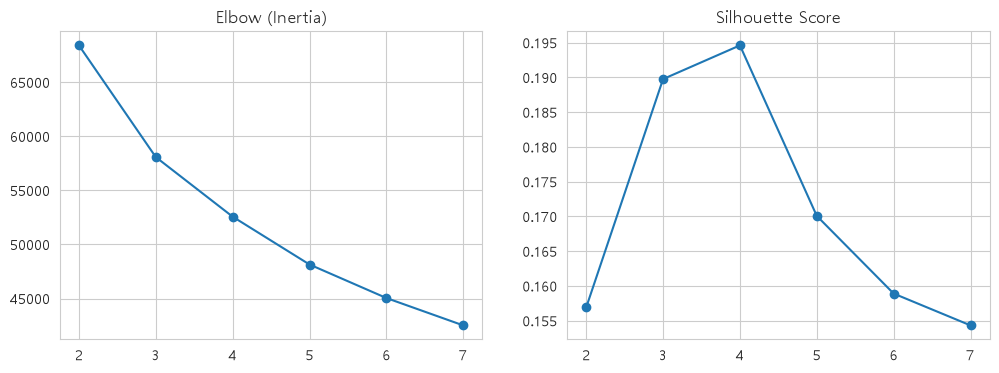

In [8]:
cluster_features = ['Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Revolving_Bal',
                    'Avg_Utilization_Ratio', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon',
                    'Total_Ct_Chng_Q4_Q1', 'Total_Amt_Chng_Q4_Q1']
X_cluster = StandardScaler().fit_transform(df[cluster_features])

inertias, sil_scores = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(K_range, inertias, marker='o'); ax[0].set_title('Elbow (Inertia)')
ax[1].plot(K_range, sil_scores, marker='o'); ax[1].set_title('Silhouette Score')
plt.show()

### 5-1. 최종 군집 적합 및 세그먼트 프로파일링
결정한 k로 최종 군집화 후, 세그먼트별 평균 특성 확인 → "저활동군", "고빈도 저금액군", "고금액 저빈도군" 등 이름 부여.

In [9]:
k_final = 4  # elbow/silhouette 결과 보고 조정
kmeans_final = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=10)
df['segment'] = kmeans_final.fit_predict(X_cluster)

segment_profile = df.groupby('segment')[cluster_features + ['Churn']].mean().round(2)
segment_profile['customer_count'] = df['segment'].value_counts()
segment_profile

,Total_Trans_Amt,Total_Trans_Ct,Total_Revolving_Bal,Avg_Utilization_Ratio,Months_Inactive_12_mon,Contacts_Count_12_mon,Total_Ct_Chng_Q4_Q1,Total_Amt_Chng_Q4_Q1,Churn,customer_count
segment,,,,,,,,,,
0,12592.36,104.20,1418.94,0.17,2.19,2.16,0.73,0.78,0.03,1103
1,3668.60,64.70,1722.89,0.50,2.33,2.37,0.69,0.72,0.09,4185
2,3365.75,58.53,400.39,0.05,2.46,2.65,0.64,0.70,0.31,3782
3,2486.69,47.06,1406.01,0.28,2.13,2.42,1.04,1.12,0.04,1057


### 5-2. 신용여력군 군집 (대안 비교)
`Credit_Limit`/`Avg_Open_To_Buy`/`Avg_Utilization_Ratio`/`Total_Revolving_Bal`(신용여력 4개 피처)만으로 군집화하면 k=2에서 Silhouette **0.47**로 뚜렷하게 갈린다 — "일반 한도군" vs "고한도 저활용군".

신용 한도/평균 대출 가능 금액/평균 대출 사용률/리볼빙(이월)잔액

In [10]:
credit_features = ['Credit_Limit', 'Avg_Open_To_Buy', 'Avg_Utilization_Ratio', 'Total_Revolving_Bal']
X_credit = StandardScaler().fit_transform(df[credit_features])

credit_K_range = range(2, 8)
credit_sil_scores = []
for k in credit_K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_credit)
    credit_sil_scores.append(silhouette_score(X_credit, km.labels_))

credit_k_final = list(credit_K_range)[int(np.argmax(credit_sil_scores))]
print(f'신용여력군 선택된 k: {credit_k_final} (Silhouette={max(credit_sil_scores):.4f})')

kmeans_credit = KMeans(n_clusters=credit_k_final, random_state=RANDOM_STATE, n_init=10)
df['credit_segment'] = kmeans_credit.fit_predict(X_credit)

credit_segment_profile = df.groupby('credit_segment')[credit_features + ['Churn']].mean().round(3)
credit_segment_profile['customer_count'] = df['credit_segment'].value_counts()
credit_segment_profile

신용여력군 선택된 k: 2 (Silhouette=0.4687)


,Credit_Limit,Avg_Open_To_Buy,Avg_Utilization_Ratio,Total_Revolving_Bal,Churn,customer_count
credit_segment,,,,,,
0,24672.674,23555.453,0.048,1117.221,0.148,1994
1,4699.186,3525.194,0.331,1173.992,0.164,8133


### 5-3. 신용여력군 PCA 시각화
2차원으로 축소해 두 군집이 실제로 시각적으로 분리되는지 확인.

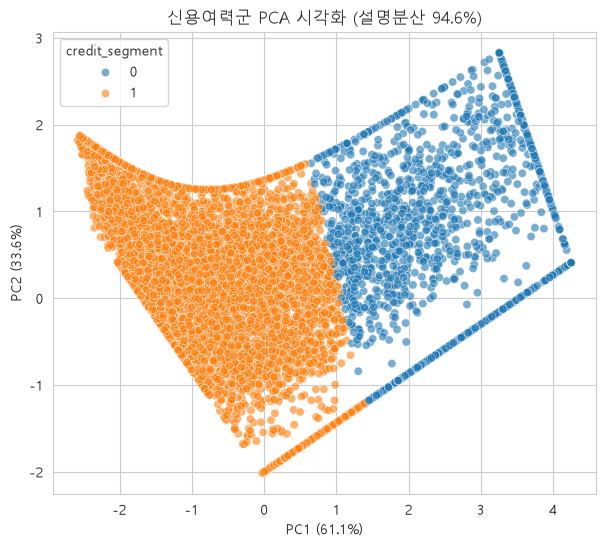

In [11]:
from sklearn.decomposition import PCA

pca_credit = PCA(n_components=2, random_state=RANDOM_STATE)
X_credit_pca = pca_credit.fit_transform(X_credit)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=X_credit_pca[:, 0], y=X_credit_pca[:, 1], hue=df['credit_segment'], palette='tab10', alpha=0.6)
plt.title(f'신용여력군 PCA 시각화 (설명분산 {pca_credit.explained_variance_ratio_.sum():.1%})')
plt.xlabel(f'PC1 ({pca_credit.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca_credit.explained_variance_ratio_[1]:.1%})')
plt.show()

### 5-3-1. 실제 단위 기준 시각화 (해석 쉬운 버전)
PC1/PC2는 축 의미를 따로 설명해야 해서 직관적이지 않다. 대신 PC1을 실질적으로 구성하는 두 원본 피처(신용한도, 이용률)를 그대로 x/y축으로 써서, 축 값 자체가 바로 "얼마"인지 읽을 수 있게 그린다.

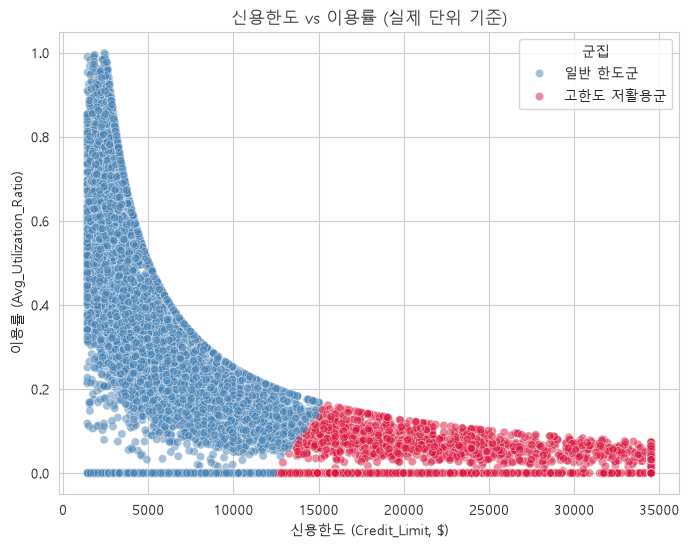

In [12]:
high_limit_cluster = credit_segment_profile['Credit_Limit'].idxmax()
low_limit_cluster = credit_segment_profile['Credit_Limit'].idxmin()
segment_labels = {high_limit_cluster: '고한도 저활용군', low_limit_cluster: '일반 한도군'}
df['credit_segment_label'] = df['credit_segment'].map(segment_labels)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='Credit_Limit', y='Avg_Utilization_Ratio',
    hue='credit_segment_label', alpha=0.5,
    palette={'일반 한도군': 'steelblue', '고한도 저활용군': 'crimson'}
)
plt.title('신용한도 vs 이용률 (실제 단위 기준)')
plt.xlabel('신용한도 (Credit_Limit, $)')
plt.ylabel('이용률 (Avg_Utilization_Ratio)')
plt.legend(title='군집')
plt.show()

일반 한도군(80%): 한도 대비 이용률 33% 이탈률 16.4%
고한도 저활용군(20%) 이탈률 14.8%

### 5-4. 세그먼트 → 캠페인 매핑 예시
군집 결과를 리텐션 캠페인 대상 로직에 연결 (예: 저활동 세그먼트 → 더블포인트 캠페인).

In [13]:
def map_segment_to_campaign(row):
    if row['Months_Inactive_12_mon'] >= segment_profile['Months_Inactive_12_mon'].median() and row['Total_Trans_Ct'] < df['Total_Trans_Ct'].median():
        return '저활동 더블포인트 캠페인'
    if row['Total_Trans_Amt'] > df['Total_Trans_Amt'].quantile(0.75) and row['Total_Trans_Ct'] < df['Total_Trans_Ct'].median():
        return '프리미엄 업셀 캠페인'
    if row['Churn'] == 1 or row.get('churn_risk_score', 0) >= risk_threshold:
        return '이탈 위험 리베이트 캠페인'
    return '일반 유지 관리'

df['recommended_campaign'] = df.apply(map_segment_to_campaign, axis=1)
df['recommended_campaign'].value_counts()

recommended_campaign
일반 유지 관리          7011
저활동 더블포인트 캠페인     2344
이탈 위험 리베이트 캠페인     678
프리미엄 업셀 캠페인         94
Name: count, dtype: int64

## 6. [회귀] 향후 이용금액(Total_Trans_Amt) 예측
**비즈니스 활용**: 프리미엄 업셀 대상(고금액·저빈도 우량 고객) 산출, 매출 예측 기반 Analytics 리포트.
- 신용한도, 리볼빙잔액, 이용횟수 등으로 이용금액 회귀 예측

In [14]:
reg_features = ['Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Trans_Ct',
                'Total_Relationship_Count', 'Months_on_book', 'Avg_Utilization_Ratio']
Xr = df[reg_features]
yr = df['Total_Trans_Amt']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)

reg = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
reg.fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)

print('MAE:', mean_absolute_error(yr_test, yr_pred))
print('RMSE:', np.sqrt(mean_squared_error(yr_test, yr_pred)))
print('R2:', r2_score(yr_test, yr_pred))

MAE: 795.1202314475313
RMSE: 1377.5753291533204
R2: 0.8337666324659843


### 6-1. 예측 이용금액 대비 저빈도 고객 = 프리미엄 업셀 후보
예측된 잠재 이용금액이 높은데 실제 거래빈도(Total_Trans_Ct)가 낮은 고객을 업셀 타겟으로 추출.

In [15]:
df['predicted_trans_amt'] = reg.predict(df[reg_features])
premium_upsell_candidates = df[
    (df['predicted_trans_amt'] >= df['predicted_trans_amt'].quantile(0.75)) &
    (df['Total_Trans_Ct'] <= df['Total_Trans_Ct'].quantile(0.4))
]
print(f'프리미엄 업셀 후보: {len(premium_upsell_candidates)}명')
premium_upsell_candidates[['predicted_trans_amt', 'Total_Trans_Ct', 'Credit_Limit']].head(10)

프리미엄 업셀 후보: 63명


,predicted_trans_amt,Total_Trans_Ct,Credit_Limit
1488,4772.980000,61,5655.0
3870,7810.473333,60,5420.0
4044,4898.620000,58,5597.0
4791,5186.546667,54,10195.0
4973,4726.456667,61,1538.0
6059,4965.146667,60,4776.0
7812,4883.590000,61,3659.0
7908,4839.583333,61,13679.0
7958,4981.770000,59,2765.0
7981,5034.006667,60,7744.0


## 7. 비즈니스 캠페인 세그먼트 정의 (규칙 기반)
4장(이탈확률) · 5장(군집) · 6장(예측이용금액) 결과를 조합해 실무 캠페인에 바로 매핑되는 **8개 세그먼트**를 규칙 기반으로 정의.
한 고객이 여러 조건을 동시에 만족할 수 있어 **우선순위**를 두고 1인 1세그먼트로 배정(리스크 대응 > 핵심고객 유지 > 업셀 > 활성화 순).

In [16]:
# 세그먼트 기준값(분위수) 계산 — 여러 세그먼트 규칙에서 재사용
q75_amt = df['Total_Trans_Amt'].quantile(0.75)
q60_amt = df['Total_Trans_Amt'].quantile(0.60)
q75_ct = df['Total_Trans_Ct'].quantile(0.75)
q40_ct = df['Total_Trans_Ct'].quantile(0.40)
median_ct = df['Total_Trans_Ct'].median()
q75_limit = df['Credit_Limit'].quantile(0.75)
q25_util = df['Avg_Utilization_Ratio'].quantile(0.25)
median_util = df['Avg_Utilization_Ratio'].median()
q25_age = df['Customer_Age'].quantile(0.25)
median_rel = df['Total_Relationship_Count'].median()
q75_pred_amt = df['predicted_trans_amt'].quantile(0.75)

### 7-1. 저활동·고이탈위험군
- **사용 컬럼**: `churn_risk_score`(4장 분류모델 산출), `Months_Inactive_12_mon`, `Total_Trans_Ct`
- **정의**: 이탈확률 상위 15% 이거나, 3개월 이상 미사용 + 이용건수 중위수 미만
- **비즈니스 결론**: 이탈 임박 신호가 뚜렷한 고객군. 리베이트·CS 우선 콜 등 즉각 리텐션 액션이 필요하며, 방치 시 매출 이탈로 직결됨

In [17]:
mask_risk = (df['churn_risk_score'] >= risk_threshold) | \
            ((df['Months_Inactive_12_mon'] >= 3) & (df['Total_Trans_Ct'] < median_ct))
print(f'저활동·고이탈위험군: {mask_risk.sum()}명')

저활동·고이탈위험군: 3000명


### 7-2. VIP 고사용 우량고객군
- **사용 컬럼**: `Total_Trans_Amt`, `Total_Trans_Ct`
- **정의**: 이용금액·이용건수 모두 상위 25%
- **비즈니스 결론**: 매출 기여도가 가장 큰 핵심 고객. 이탈 시 타격이 크므로 VIP 전담 관리·리워드 강화로 록인(lock-in) 우선순위 최상위

In [18]:
mask_vip = (df['Total_Trans_Amt'] >= q75_amt) & (df['Total_Trans_Ct'] >= q75_ct)
print(f'VIP 고사용 우량고객군: {mask_vip.sum()}명')

VIP 고사용 우량고객군: 1695명


### 7-3. 프리미엄 후보군 업셀링
- **사용 컬럼**: `predicted_trans_amt`(6장 회귀모델 산출), `Total_Trans_Ct`, `Card_Category`
- **정의**: 예측 이용금액 상위 25% + 실제 이용건수 하위 40% + 현재 Platinum 미보유
- **비즈니스 결론**: 잠재 소비력은 높은데 실사용이 낮은 고객. 한도상향·상위카드 제안으로 실사용 전환을 유도하면 매출 확대 여지가 큼

In [19]:
mask_premium_upsell = (df['predicted_trans_amt'] >= q75_pred_amt) & \
                      (df['Total_Trans_Ct'] <= q40_ct) & (df['Card_Category'] != 'Platinum')
print(f'프리미엄 후보군 업셀링: {mask_premium_upsell.sum()}명')

프리미엄 후보군 업셀링: 63명


### 7-4. 고한도 저활용 잠재우량군
- **사용 컬럼**: `Credit_Limit`, `Avg_Utilization_Ratio`
- **정의**: 신용한도 상위 25% + 이용률 하위 25%
- **비즈니스 결론**: 카드사가 이미 우량고객으로 판단(높은 한도)했지만 실사용이 낮아 미실현 매출 상태. 첫 결제 캐시백 등 이용 활성화 캠페인이 효과적

In [20]:
mask_high_limit_low_use = (df['Credit_Limit'] >= q75_limit) & (df['Avg_Utilization_Ratio'] <= q25_util)
print(f'고한도 저활용 잠재우량군: {mask_high_limit_low_use.sum()}명')

고한도 저활용 잠재우량군: 666명


### 7-5. 대중 리볼버(이자수익)군
- **사용 컬럼**: `Total_Revolving_Bal`, `Avg_Utilization_Ratio`
- **정의**: 리볼빙 잔액 보유(>0) + 이용률 중위수 이상
- **비즈니스 결론**: 리볼빙 이자수익에 꾸준히 기여하는 고객군. 완납을 유도하기보다 리볼빙 한도상향·이자우대 등으로 관계를 유지하는 편이 수익성에 유리

In [21]:
mask_revolver = (df['Total_Revolving_Bal'] > 0) & (df['Avg_Utilization_Ratio'] >= median_util)
print(f'대중 리볼버(이자수익)군: {mask_revolver.sum()}명')

대중 리볼버(이자수익)군: 5064명


### 7-6. 신규 골드카드 전환 캠페인
- **사용 컬럼**: `Card_Category`, `Total_Trans_Amt`, `Total_Relationship_Count`
- **정의**: Blue/Silver 등급 + 이용금액 상위 40% + 보유상품 수(관계 깊이) 중위수 이상
- **비즈니스 결론**: 이용실적은 준수한데 카드 등급이 낮은 미스매치 고객. 골드카드 전환 프로모션으로 등급업을 유도하면 수수료 수익 증가와 록인 강화를 동시에 기대 가능

In [22]:
mask_gold_upgrade = df['Card_Category'].isin(['Blue', 'Silver']) & \
                    (df['Total_Trans_Amt'] >= q60_amt) & (df['Total_Relationship_Count'] >= median_rel)
print(f'신규 골드카드 전환 캠페인: {mask_gold_upgrade.sum()}명')

신규 골드카드 전환 캠페인: 1731명


### 7-7. 고소득층 프리미엄 혜택 안내
- **사용 컬럼**: `Income_Category`, `Card_Category`
- **정의**: 소득 $80K 이상 + 카드 등급은 최하위(Blue)
- **비즈니스 결론**: 소득 대비 보유 카드 혜택이 낮은 미스매치 고객. 프리미엄 카드/혜택 안내만으로도 상향 전환 가능성이 높은 저비용 고효율 타겟

In [23]:
mask_high_income = df['Income_Category'].isin(['$80K - $120K', '$120K +']) & (df['Card_Category'] == 'Blue')
print(f'고소득층 프리미엄 혜택 안내: {mask_high_income.sum()}명')

고소득층 프리미엄 혜택 안내: 2040명


### 7-8. 청년 고객 이용 활성화
- **사용 컬럼**: `Customer_Age`, `Total_Trans_Ct`
- **정의**: 연령 하위 25% + 이용건수 중위수 미만
- **비즈니스 결론**: 생애주기 초반이라 카드 이용 습관이 아직 자리 잡지 않은 고객. 장기 LTV 확보를 위해 초기 리워드·구독형 혜택으로 이용 습관을 조기에 형성시켜야 함

In [24]:
mask_young = (df['Customer_Age'] <= q25_age) & (df['Total_Trans_Ct'] < median_ct)
print(f'청년 고객 이용 활성화: {mask_young.sum()}명')

청년 고객 이용 활성화: 1448명


### 7-9. 1인 1세그먼트 배정 및 세그먼트별 요약
위 8개 조건에 우선순위를 적용해 고객마다 하나의 `business_segment`를 배정하고, 세그먼트별 규모·이탈률·평균 이용금액·평균 신용한도를 확인.

In [25]:
conditions = [mask_risk, mask_vip, mask_premium_upsell, mask_high_limit_low_use,
              mask_revolver, mask_gold_upgrade, mask_high_income, mask_young]
choices = ['저활동·고이탈위험군', 'VIP 고사용 우량고객군', '프리미엄 후보군 업셀링', '고한도 저활용 잠재우량군',
           '대중 리볼버(이자수익)군', '신규 골드카드 전환 캠페인', '고소득층 프리미엄 혜택 안내', '청년 고객 이용 활성화']
df['business_segment'] = np.select(conditions, choices, default='일반 유지관리')

seg_summary = df.groupby('business_segment').agg(
    고객수=('Churn', 'size'),
    이탈률=('Churn', 'mean'),
    평균이용금액=('Total_Trans_Amt', 'mean'),
    평균신용한도=('Credit_Limit', 'mean')
).round(3).sort_values('고객수', ascending=False)
seg_summary

,고객수,이탈률,평균이용금액,평균신용한도
business_segment,,,,
대중 리볼버(이자수익)군,3041,0.008,3627.367,3697.959
저활동·고이탈위험군,3000,0.519,2737.974,8447.891
VIP 고사용 우량고객군,1669,0.003,10093.613,11444.971
일반 유지관리,1084,0.014,3529.254,10443.841
고소득층 프리미엄 혜택 안내,495,0.012,2929.929,18668.540
신규 골드카드 전환 캠페인,380,0.011,4621.582,8332.549
고한도 저활용 잠재우량군,296,0.030,3518.649,21212.726
청년 고객 이용 활성화,147,0.034,2480.068,10448.231
프리미엄 후보군 업셀링,15,0.200,4725.467,12113.000


고객수 - 이탈률 - 12개월 평균이용금액 - 평균신용한도

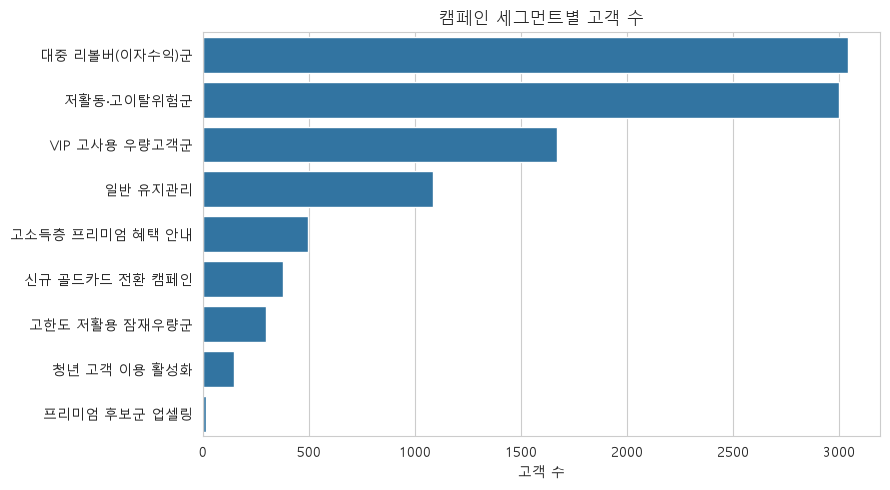

In [26]:
plt.figure(figsize=(9, 5))
sns.barplot(x=seg_summary['고객수'], y=seg_summary.index)
plt.title('캠페인 세그먼트별 고객 수')
plt.xlabel('고객 수')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 7-10. 세그먼트 정리표 (요약)

| 세그먼트 | 사용 컬럼 | 비즈니스 결론 |
|---|---|---|
| 저활동·고이탈위험군 | churn_risk_score, Months_Inactive_12_mon, Total_Trans_Ct | 이탈 임박 신호 → 즉각 리텐션(리베이트·CS콜) |
| VIP 고사용 우량고객군 | Total_Trans_Amt, Total_Trans_Ct | 핵심 매출원 → VIP 전담 관리로 록인 최우선 |
| 프리미엄 후보군 업셀링 | predicted_trans_amt, Total_Trans_Ct, Card_Category | 잠재 소비력 높음·저사용 → 상위카드/한도 업셀 |
| 고한도 저활용 잠재우량군 | Credit_Limit, Avg_Utilization_Ratio | 미실현 매출 → 첫 결제 캐시백으로 활성화 |
| 대중 리볼버(이자수익)군 | Total_Revolving_Bal, Avg_Utilization_Ratio | 이자수익 기여 → 완납유도 대신 리볼빙 혜택 유지 |
| 신규 골드카드 전환 캠페인 | Card_Category, Total_Trans_Amt, Total_Relationship_Count | 실적 대비 낮은 등급 → 골드카드 전환 프로모션 |
| 고소득층 프리미엄 혜택 안내 | Income_Category, Card_Category | 소득 대비 낮은 등급 → 프리미엄 혜택 안내로 상향 |
| 청년 고객 이용 활성화 | Customer_Age, Total_Trans_Ct | 초기 생애주기·저이용 → 습관형성형 리워드로 LTV 확보 |

공통적으로, 세그먼트 정의는 **분류(이탈확률)·회귀(예측이용금액)·원본 이용/한도 지표**를 조합한 규칙이며, 우선순위 배정으로 캠페인 중복 없이 1인 1타겟팅이 가능하도록 설계.

## 8. 모델 비교 요약 및 저장
분류/회귀 모델 성능 요약표 + 최종 모델 저장(pickle) → 대시보드/백엔드 연동 할때

In [ ]:
#사용안함
# import joblib

# summary = pd.DataFrame({
#     'Model': ['RandomForestClassifier (Churn)', 'RandomForestRegressor (Trans Amt)'],
#     'Metric': ['ROC-AUC', 'R2'],
#     'Score': [roc_auc_score(y_test, proba), r2_score(yr_test, yr_pred)]
# })
# display(summary)

# joblib.dump(clf, 'churn_model.pkl')
# joblib.dump(reg, 'trans_amt_model.pkl')
# joblib.dump(kmeans_final, 'segment_model.pkl')
# print('모델 저장 완료')

,Model,Metric,Score
0,RandomForestClassifier (Churn),ROC-AUC,0.985682
1,RandomForestRegressor (Trans Amt),R2,0.833767


모델 저장 완료


## 9. 산출물 매핑
- **Analytics**: `segment` (군집), `segment_profile`, `predicted_trans_amt` → 카드 이용 트렌드/세그먼트 리포트
- **Operations**: `churn_risk_score` 상위 고객 → CS 우선 응대 리스트, SMS 발송 대상 필터
- **Marketing**: `recommended_campaign` 컬럼 → 이탈 리베이트/저활동 더블포인트/프리미엄 업셀 캠페인 자동 타겟팅

## 10. 세그먼트별 시각화
`business_segment`(7장에서 정의한 캠페인 8종 + 일반 유지관리, 총 9개)별로 **이용금액×이용건수 산점도**(이탈 여부 색상 구분)와 **이용률 분포**를 for문으로 일괄 생성 → 세그먼트 간 행동 패턴 차이를 한눈에 비교.

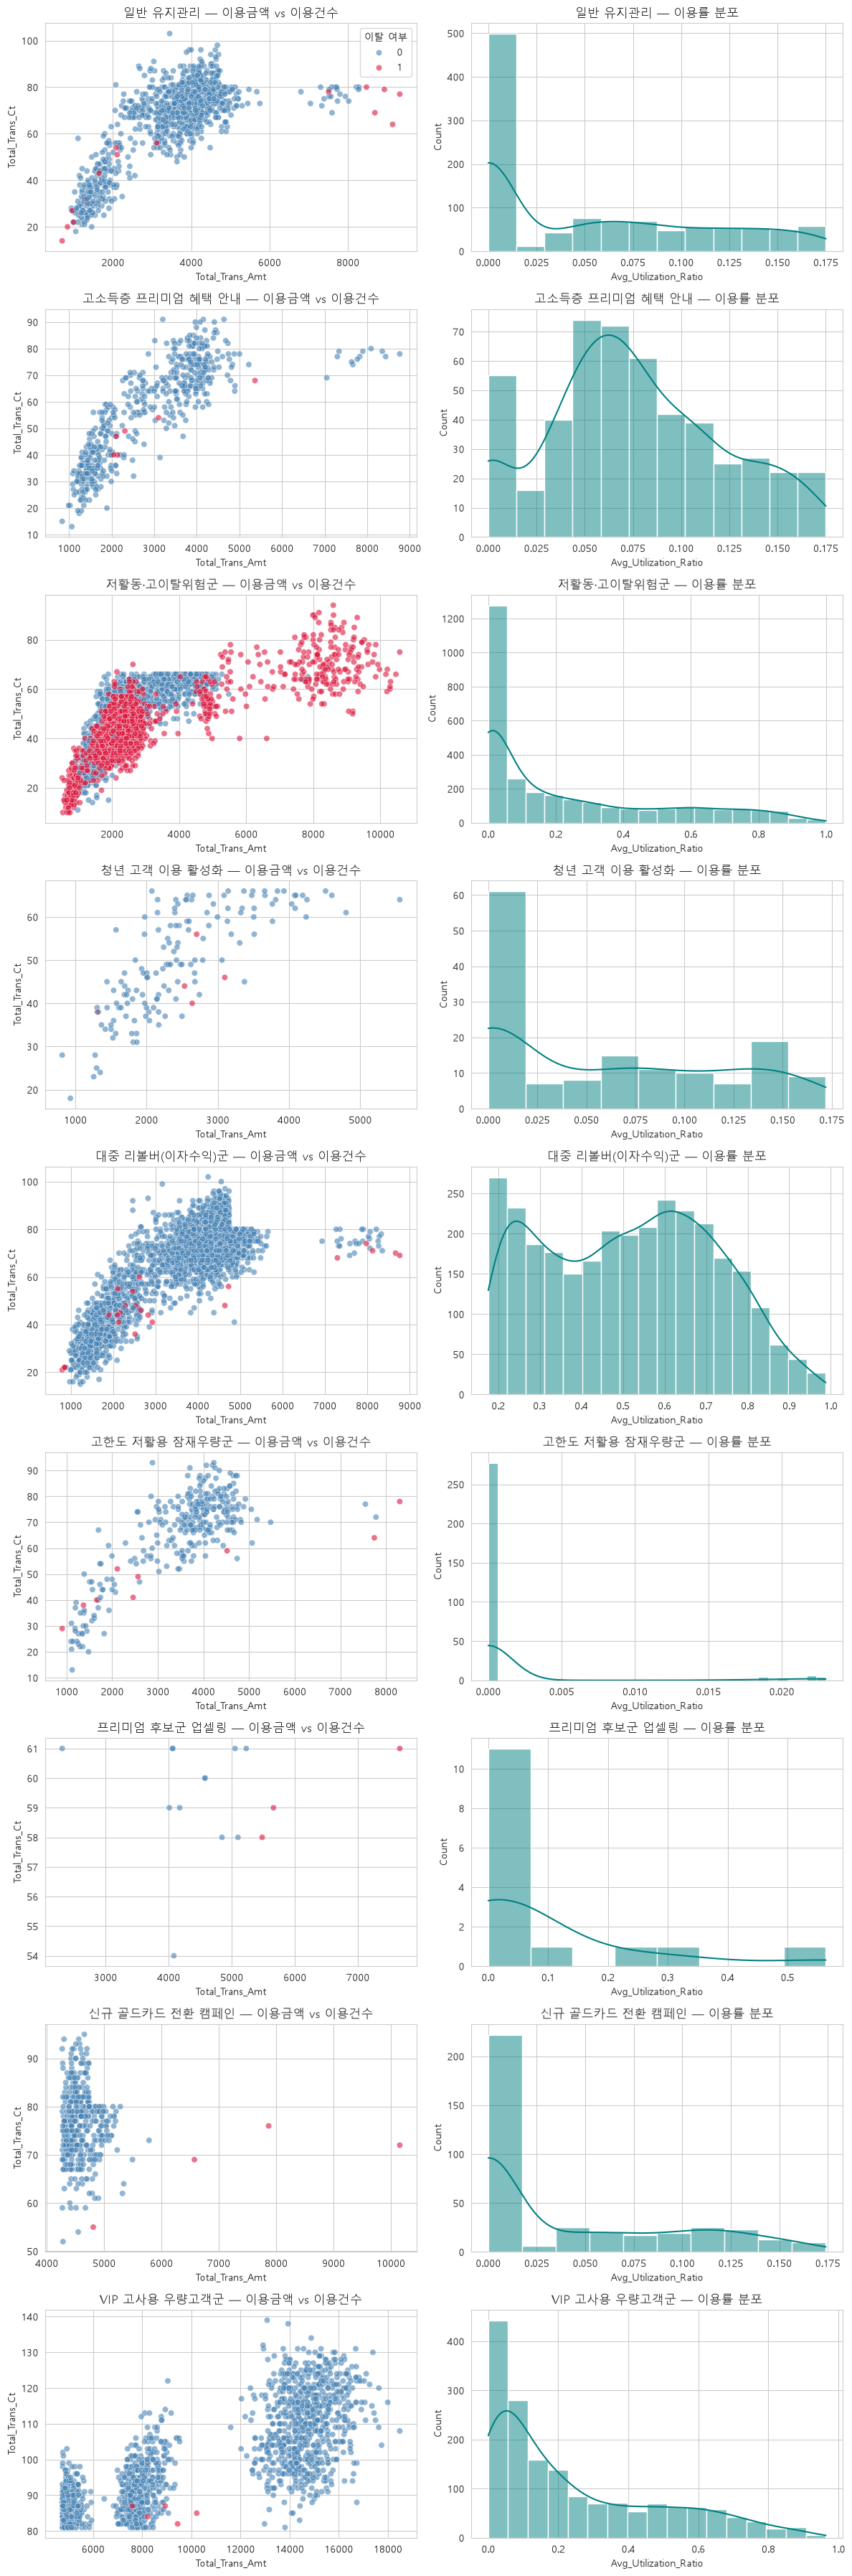

In [28]:
segments = df['business_segment'].unique()
n = len(segments)
fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))

for i, seg in enumerate(segments):
    seg_df = df[df['business_segment'] == seg]

    sns.scatterplot(
        data=seg_df, x='Total_Trans_Amt', y='Total_Trans_Ct',
        hue='Churn', palette={0: 'steelblue', 1: 'crimson'},
        alpha=0.6, ax=axes[i, 0], legend=(i == 0)
    )
    axes[i, 0].set_title(f'{seg} — 이용금액 vs 이용건수')
    if i == 0:
        axes[i, 0].legend(title='이탈 여부')

    sns.histplot(
        data=seg_df, x='Avg_Utilization_Ratio', kde=True,
        color='teal', ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'{seg} — 이용률 분포')

plt.tight_layout()
plt.show()